<br><br>

<center>

<h2><b>Assignment 3</b></h2>

<br><br>

<h3>Department of Mathematics and Statistics</h3>
<h3>University of Calgary</h3>

<br><br>

<h4>Statistical and Machine Learning</h4>
<h4>Winter 2026</h4>

</center>

<br><br>

This assignment covers material from **Lectures 7 and 8**.

---

### Assignment Overview

In this assignment, you will practice key ideas from **deep learning** and **classical natural language processing**.

You will first work with a **convolutional neural network (CNN)** for image classification using the SVHN dataset. Then, you will work with a **text classification** problem using standard NLP representations and models such as **Bag-of-Words**, **TF-IDF**, **Naive Bayes**, and **Logistic Regression**.

This assignment is divided into two questions:

- **Question 1:** Convolutional Neural Networks (CNN)  
- **Question 2:** Classical NLP for Text Classification  

By the end of this assignment, you should understand how convolutional architectures are used for supervised image classification, and how traditional NLP pipelines convert raw text into features for machine learning models.

---

### AI Policy

Assignments in this course must be completed **independently**. You may use generative AI tools only as a guide for:

- brainstorming,
- clarification of concepts,
- feedback on understanding.

However, AI tools must **not** be used to generate full solutions for direct submission. If you use any external resources, including AI tools, you must reference them appropriately.

#### Important Note on Academic Integrity

Submitting code or results that are directly copied and pasted from AI tools, or from any external source, without understanding is not acceptable.

If an assignment submission appears to rely heavily on AI-generated solutions, the student may be asked to meet with the instructor or TA to **explain their work and justify their approach**.

Students are fully responsible for the originality, correctness, and understanding of their submitted work.

---

### Submission Instructions (D2L)

You must submit **one Jupyter notebook file** (`.ipynb`) on D2L.

Your submission file must be named using the following format:

`FirstName_LastName_UCID.ipynb`

For example, if your name is *Sara Smith* and your UCID is *123456789*, then your file should be:

`Sara_Smith_123456789.ipynb`

---

### How to Save Your Notebook as a `.ipynb` File

To export your work from Jupyter Notebook:

1. Go to the top menu: **File**
2. Click: **Download**

Finally, rename the file using the required format and upload it to **D2L** before the deadline.

---

### Important Note on Completing the Assignment

Throughout this notebook, you will see code blocks marked clearly with:

```python
# -----------------------
# write your code here
# -----------------------
```

- You must write your answers **only** inside these designated sections. **Do not modify or delete** any other parts of the notebook, as the assignment will be graded based on these specific code blocks.
- Each coding part includes a **correctness check** cell so you can verify that your implementation is working before moving forward.
- For Question 1, it is also **your responsibility** to make sure that your CNN model is not clearly overfitted. Use the training and test results to support your discussion where required.


## Table of Contents

- [Required Packages](#Required-Packages)
- [Question 1: CNN Practice on SVHN](#Question-1:-CNN-Practice-on-SVHN)
  - [1.1: Load the Data, Define the Transforms, and Explore the Dataset](#1.1:-Load-the-Data,-Define-the-Transforms,-and-Explore-the-Dataset)
  - [[TO BE COMPLETED] 1.2: Build Your Own CNN Model](#%5BTO-BE-COMPLETED%5D-1.2:-Build-Your-Own-CNN-Model)
  - [[TO BE COMPLETED] 1.3: Train and Evaluate the Model](#%5BTO-BE-COMPLETED%5D-1.3:-Train-and-Evaluate-the-Model)
  - [[TO BE COMPLETED] 1.4: Plot the Training Curves](#%5BTO-BE-COMPLETED%5D-1.4:-Plot-the-Training-Curves)
  - [[TO BE COMPLETED] 1.5: Answer the Questions Below](#%5BTO-BE-COMPLETED%5D-1.5:-Answer-the-Questions-Below)
- [Question 2: Classical NLP for Text Classification](#Question-2:-Classical-NLP-for-Text-Classification)
  - [[TO BE COMPLETED] 2.1: Load and Inspect the Dataset](#%5BTO-BE-COMPLETED%5D-2.1:-Load-and-Inspect-the-Dataset)
  - [[TO BE COMPLETED] 2.2: Split the Data and Create Bag-of-Words Features](#%5BTO-BE-COMPLETED%5D-2.2:-Split-the-Data-and-Create-Bag-of-Words-Features)
  - [[TO BE COMPLETED] 2.3: Train a Bag-of-Words + Naive Bayes Model](#%5BTO-BE-COMPLETED%5D-2.3:-Train-a-Bag-of-Words-+-Naive-Bayes-Model)
  - [[TO BE COMPLETED] 2.4: Train a TF-IDF + Logistic Regression Model](#%5BTO-BE-COMPLETED%5D-2.4:-Train-a-TF-IDF-+-Logistic-Regression-Model)
  - [[TO BE COMPLETED] 2.5: Answer the Questions Below](#%5BTO-BE-COMPLETED%5D-2.5:-Answer-the-Questions-Below)


## Required Packages
If a package or dataset is not available in your environment, it is your responsibility to install or download it before running the notebook.

In [ ]:

# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import SVHN

import nltk
from nltk.corpus import movie_reviews

from scipy.sparse import issparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


# Question 1: CNN Practice on SVHN

In this question, you will build and train a **Convolutional Neural Network (CNN)** on the **SVHN** dataset. SVHN (Street View House Numbers) is a real-world image classification dataset of house-number digits.

Your goal is to design, train, and evaluate a CNN that achieves a **test accuracy above 0.75**. You are **not** given the architecture, learning rate, or number of epochs. You must make these choices yourself and justify them through your results.

It is also **your responsibility** to monitor your model and make sure it is **not overfitted**. In other words, you should compare training and test performance and avoid a model that memorizes the training data but generalizes poorly to the test data.

### 1.1: Load the Data and Define the Transforms

In this part, we import the data-loading pipeline for the **full SVHN dataset** and define the transforms used for the training and test sets.

The images are RGB with shape **32 × 32 × 3**, and the labels are digits from **0** to **9**.  
The transforms should convert the images into tensors. You may also include preprocessing steps such as normalization. If random augmentation is used, it should be applied only to the training data and not to the test data.test data loader should not.ween **64** and **256**.

100%|██████████| 182M/182M [00:24<00:00, 7.39MB/s]
100%|██████████| 64.3M/64.3M [00:28<00:00, 2.25MB/s]


Training size: 73257
Test size: 26032
Shape of one training image: torch.Size([3, 32, 32])
Label of one training image: 1
Shape of one batch of images: torch.Size([128, 3, 32, 32])
Shape of one batch of labels: torch.Size([128])


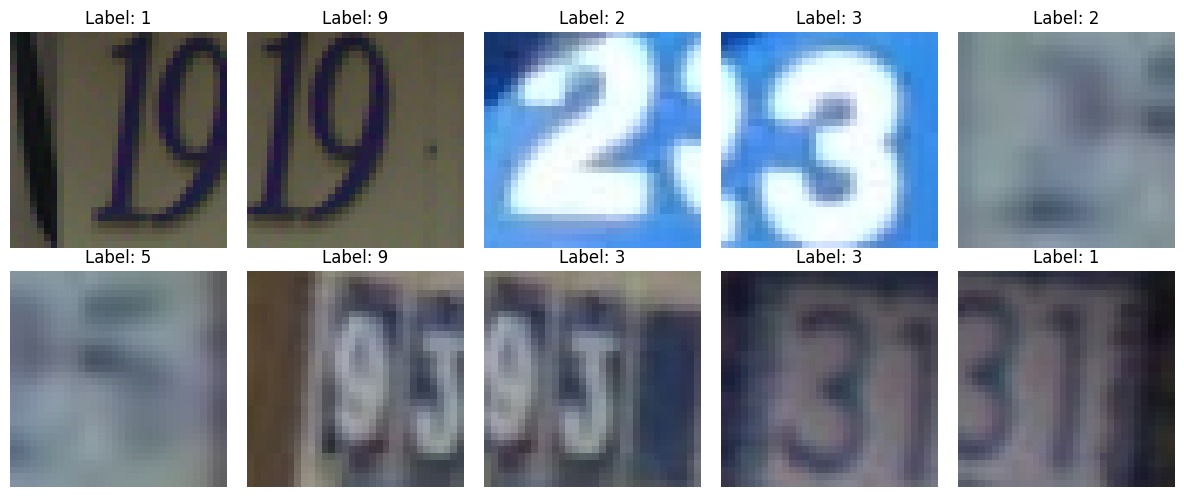

In [ ]:
train_transform = transforms.Compose([
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = SVHN(root="./data", split="train", download=True, transform=train_transform)
test_dataset = SVHN(root="./data", split="test", download=True, transform=test_transform)

train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True
)
test_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False
)

print("Training size:", len(train_dataset))
print("Test size:", len(test_dataset))

image, label = train_dataset[0]
print("Shape of one training image:", image.shape)
print("Label of one training image:", label)

images, labels = next(iter(train_loader))
print("Shape of one batch of images:", images.shape)
print("Shape of one batch of labels:", labels.shape)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img, lbl = train_dataset[i]
    img = img.permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f"Label: {lbl}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### [TO BE COMPLETED] 1.2: Build Your Own CNN Model

Design your own convolutional neural network for the SVHN classification task.

Your model must satisfy the following requirements:

- the input is a color image with shape **3 × 32 × 32**,
- the output must have **10 units** for the 10 digit classes,
- the model must contain at least one **convolutional layer**,
- the model must be valid for multi-class classification.

You must decide the architecture yourself. This includes, for example:

- the number of convolutional layers,
- the number of filters,
- whether to use pooling layers,
- the number and size of fully connected layers,
- whether to use dropout or batch normalization.

**Hints:**
- Start with a small or medium-size CNN rather than an overly deep model.
- Using `ReLU`, `MaxPool2d`, `Dropout`, or `BatchNorm2d` may help.
- Make sure the final layer produces **10 logits**.
- Your architecture should be strong enough to reach the required test accuracy, but not unnecessarily complex.

In [ ]:
class SVHNCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# ----------------------------
# CORRECTNESS CHECK
# ----------------------------
x_dummy = torch.randn(4, 3, 32, 32).to(device)
y_dummy = model(x_dummy)
assert y_dummy.shape == (4, 10), "Model output shape should be (batch_size, 10)."
assert torch.is_floating_point(y_dummy), "Model outputs should be floating-point logits."

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert num_params > 0, "Your model must have trainable parameters."

print("Model definition seems correct.")

Model definition seems correct.


### [TO BE COMPLETED] 1.3: Train and Evaluate the Model

Train your model on the full SVHN training set and evaluate it on the test set.

In this part, you must choose appropriate training settings yourself. In particular, you must choose:

- a suitable loss function,
- an optimizer,
- a learning rate,
- the number of training epochs.

You should store the training loss, training accuracy, and test accuracy at each epoch.

Your final model must reach a **test accuracy above 0.75**.

You are also expected to think about **overfitting**. If your training accuracy becomes very high but your test accuracy stops improving or starts getting worse, your model may be overfitting.

**Hints:**
- For multi-class classification, `nn.CrossEntropyLoss()` is often appropriate.
- Optimizers such as `Adam` is common choices.
- A learning rate such as `0.001` is a reasonable starting point, but you should decide what works best.
- Track both training and test accuracy and loss for training and test across epochs instead of looking only at the final value.

In [ ]:
# Use GPU to speed up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = SVHNCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5

train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    test_running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_loss = test_running_loss / total
    test_acc = correct / total

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Epoch 1/5 | Train Loss: 1.1098 | Test Loss: 0.6926 | Train Acc: 0.6457 | Test Acc: 0.8148
Epoch 2/5 | Train Loss: 0.5644 | Test Loss: 0.5848 | Train Acc: 0.8418 | Test Acc: 0.8372
Epoch 3/5 | Train Loss: 0.4776 | Test Loss: 0.5378 | Train Acc: 0.8657 | Test Acc: 0.8494
Epoch 4/5 | Train Loss: 0.4151 | Test Loss: 0.4859 | Train Acc: 0.8824 | Test Acc: 0.8622
Epoch 5/5 | Train Loss: 0.3710 | Test Loss: 0.4571 | Train Acc: 0.8940 | Test Acc: 0.8699


In [ ]:
# ----------------------------
# CORRECTNESS CHECK
# ----------------------------
assert len(train_losses) == num_epochs, "You must store one training loss value per epoch."
assert len(train_accs) == num_epochs, "You must store one training accuracy value per epoch."
assert len(test_accs) == num_epochs, "You must store one test accuracy value per epoch."
assert test_accs[-1] >= 0.75, "Test accuracy is lower than expected."

print("Training and evaluation seem correct.")

Training and evaluation seem correct.


### [TO BE COMPLETED] 1.4: Plot the Training Curves

Plot the training progress of the CNN for:

- the **training loss and test loss**,
- the **training accuracy and test accuracy**

as functions of the **epoch number**.

Your plot should help you judge whether the model is learning properly and whether overfitting may be happening.

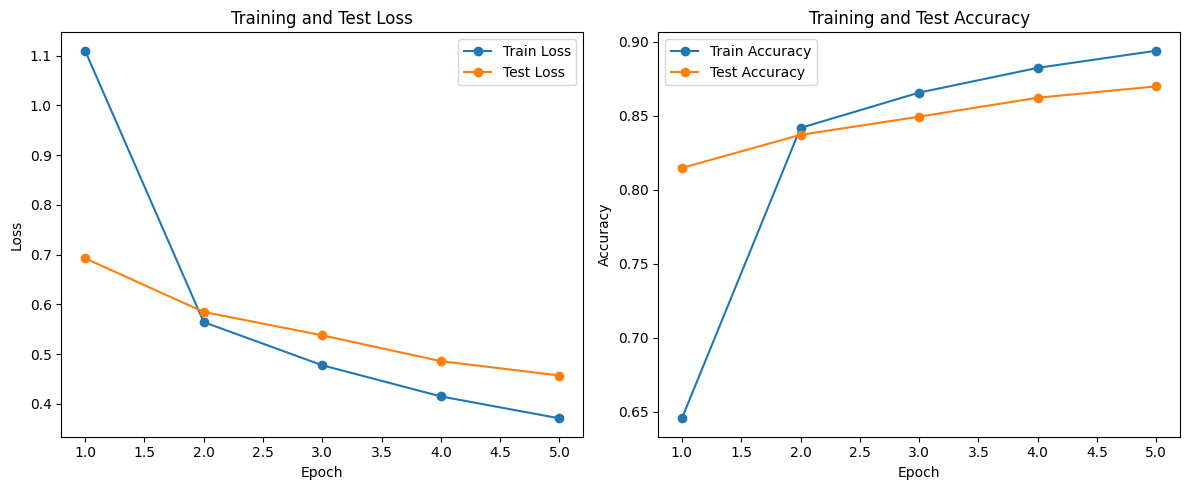

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, test_losses, marker='o', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, marker='o', label='Train Accuracy')
plt.plot(epochs, test_accs, marker='o', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### [TO BE COMPLETED] 1.5: Answer the questions below

Answer the following questions in 2–4 sentences each.

1. Briefly describe the role of the convolutional layers and the pooling layers in your CNN model.
2. Explain why you chose your architecture, learning rate, and number of epochs.
3. What is the effect of the learning rate during training? Explain what may happen if the learning rate is too high or too low.
4. What is the role of padding in a convolutional neural network? Explain how changing the padding can affect the feature maps and the final performance of the model.
5. Did your model show any signs of overfitting? Explain your answer using the training and test curves.
6. Suggest one change that might improve the model further and explain why.

**Write your answers below.**

1. The convolutional layers pass filters over the images to learn spatial features, from simple edges to more complex shapes. Pooling reduces the size of the feature maps, keeping the most important signals while improving efficiency and generalization.
2. I used a CNN with a feed-forward classifier because CNNs work well on image data where proximity matters. ReLU adds non-linearity. A learning rate of 0.001 was chosen as a standard stable value, and 5 epochs balanced training time and performance while exceeding the target accuracy.
3. The learning rate controls how large the weight updates are. If it is too high, training can become unstable or fail to converge. If it is too low, training is very slow and may not reach a good solution.
4. Padding adds pixels around the input so feature map sizes are preserved. It helps retain edge information and allows deeper networks without shrinking dimensions too quickly.
5. Training accuracy increased and loss decreased, while test accuracy also improved. Although there was a small gap, test performance did not degrade, so there was no strong evidence of overfitting.
6. One improvement would be to add dropout, which would reduce overfitting by preventing the model from relying too heavily on specific features.

# Question 2: Classical NLP for Text Classification

In this question, you will build **classical NLP** models for **sentiment classification** using the **NLTK movie reviews** dataset.

The dataset contains movie reviews labeled as:

- `pos` = positive review
- `neg` = negative review

You will use methods discussed in class such as:

- Bag-of-Words
- TF-IDF
- Naive Bayes
- Logistic Regression

Answer all written questions in complete sentences and complete all coding tasks.


## [TO BE COMPLETED] 2.1: Load and Inspect the Dataset

In this part, load the **movie_reviews** dataset from NLTK and convert it into a `pandas` DataFrame with two columns:

- `text`
- `label`

Then:

- print the total number of reviews,
- print the class counts,
- display one positive review and one negative review.

**Hints:**
- You may need to use `nltk.download('movie_reviews')`.
- The labels are stored in the review categories.
- Each review can be joined into one string using `" ".join(...)`.


In [2]:
import nltk
import pandas as pd
from nltk.corpus import movie_reviews

nltk.download("movie_reviews")

rows = []

for f in movie_reviews.fileids():
    words = movie_reviews.words(f)
    text = " ".join(words)
    label = movie_reviews.categories(f)[0]
    rows.append((text, label))

df = pd.DataFrame(rows, columns=["text", "label"])

print("Total reviews:", len(df))
print(df["label"].value_counts())

print("\nPositive review:\n", df[df["label"] == "pos"]["text"].iloc[0][:1000])
print("\nNegative review:\n", df[df["label"] == "neg"]["text"].iloc[0][:1000])

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Total reviews: 2000
label
neg    1000
pos    1000
Name: count, dtype: int64

Positive review:
 films adapted from comic books have had plenty of success , whether they ' re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there ' s never really been a comic book like from hell before . for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid ' 80s with a 12 - part series called the watchmen . to say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . the book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . in other words , don ' t dismiss this film because of its source . if you can get past the whole comic book thing , you might find another stumbling block in from hell '

In [3]:
# -----------------------
# CORRECTNESS CHECK
# -----------------------

assert 'df' in globals(), "DataFrame df is not defined."
assert isinstance(df, pd.DataFrame), "df should be a pandas DataFrame."
assert 'text' in df.columns and 'label' in df.columns, "df must contain 'text' and 'label' columns."
assert len(df) == 2000, "The movie_reviews dataset should contain 2000 reviews."
assert set(df['label'].unique()) == {'pos', 'neg'}, "Labels should be 'pos' and 'neg'."
print("2.1 check passed.")


2.1 check passed.


## [TO BE COMPLETED] 2.2: Split the Data and Create Bag-of-Words Features

In this part, split the dataset into training and test sets, then convert the text into **Bag-of-Words** features.

You should:

- use `train_test_split`,
- use `test_size=0.2`,
- use `random_state=607`,
- stratify by the label column,
- create a `CountVectorizer` with English stop words removed,
- fit the vectorizer on the training text,
- transform both the training and test text.

Then print:

- the number of training reviews,
- the number of test reviews,
- the shape of the training feature matrix,
- the shape of the test feature matrix,
- the vocabulary size.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=607, stratify=df["label"]
)

vectorizer = CountVectorizer(stop_words="english")

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

print("Number of training reviews:", len(X_train))
print("Number of test reviews:", len(X_test))
print("Shape of training feature matrix:", X_train_bow.shape)
print("Shape of test feature matrix:", X_test_bow.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Number of training reviews: 1600
Number of test reviews: 400
Shape of training feature matrix: (1600, 35945)
Shape of test feature matrix: (400, 35945)
Vocabulary size: 35945


In [6]:
# -----------------------
# CORRECTNESS CHECK
# -----------------------

from scipy.sparse import issparse

assert 'X_train_bow' in globals(), "X_train_bow is not defined."
assert 'X_test_bow' in globals(), "X_test_bow is not defined."
assert 'y_train' in globals() and 'y_test' in globals(), "y_train and y_test must be defined."
assert len(y_train) == 1600, "Training set size should be 1600."
assert len(y_test) == 400, "Test set size should be 400."
assert issparse(X_train_bow), "X_train_bow should be a sparse matrix."
assert X_train_bow.shape[0] == 1600, "Training matrix has incorrect number of rows."
assert X_test_bow.shape[0] == 400, "Test matrix has incorrect number of rows."
assert X_train_bow.shape[1] > 1000, "Vocabulary size seems too small."
print("2.2 check passed.")


2.2 check passed.


## [TO BE COMPLETED] 2.3: Train a Bag-of-Words + Naive Bayes Model

In this part, train a **Multinomial Naive Bayes** model using the Bag-of-Words features.

You should:

- fit the model on the training data,
- predict the test labels,
- compute the test accuracy,
- print the confusion matrix,
- print the classification report.

Your model should achieve a reasonable test accuracy.


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
y_pred = nb_model.predict(X_test_bow)

acc_nb = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_nb)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

print("Classification report:\n", classification_report(y_test, y_pred))



Accuracy: 0.825
Confusion matrix:
 [[173  27]
 [ 43 157]]
Classification report:
               precision    recall  f1-score   support

         neg       0.80      0.86      0.83       200
         pos       0.85      0.79      0.82       200

    accuracy                           0.82       400
   macro avg       0.83      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400



In [8]:
# -----------------------
# CORRECTNESS CHECK
# -----------------------

assert 'acc_nb' in globals(), "acc_nb is not defined."
assert 0 <= acc_nb <= 1, "Accuracy must be between 0 and 1."
assert acc_nb >= 0.75, "Accuracy is too low. Recheck your pipeline."
print("2.3 check passed.")


2.3 check passed.


## [TO BE COMPLETED] 2.4: Train a TF-IDF + Logistic Regression Model

In this part, build a second text-classification pipeline using **TF-IDF** and **Logistic Regression**.

You should:

- create a `TfidfVectorizer` with English stop words removed,
- fit it on the training text,
- transform both the training and test text,
- train a `LogisticRegression` model,
- compute the test accuracy,
- compare this accuracy with the Naive Bayes result.

Then print:

- the TF-IDF test accuracy,
- the Naive Bayes test accuracy,
- which model performed better.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_Vectorizer = TfidfVectorizer(stop_words="english")
X_train_tfidf = tfidf_Vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_Vectorizer.transform(X_test)

lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred)
print("TF-IDF test accuracy:", acc_lr)
print("Naive Bayes test accuracy:", acc_nb)
print("Logistic Regression performed better on an accuracy basis")




TF-IDF test accuracy: 0.8425
Naive Bayes test accuracy: 0.825
Logistic Regression performed better on an accuracy basis


In [13]:
# -----------------------
# CORRECTNESS CHECK
# -----------------------

assert 'acc_lr' in globals(), "acc_lr is not defined."
assert 0 <= acc_lr <= 1, "Accuracy must be between 0 and 1."
assert acc_lr >= 0.78, "Accuracy is too low. Recheck your TF-IDF + Logistic Regression pipeline."
print("2.4 check passed.")


2.4 check passed.


## [TO BE COMPLETED] 2.5: Answer the Questions Below

Answer the following questions in **2–4 sentences each**.

1. What is the main idea of the Bag-of-Words representation, and what information does it ignore?
2. Why can TF-IDF sometimes perform better than raw word counts for text classification?
3. Why are the matrices from `CountVectorizer` and `TfidfVectorizer` usually sparse?
4. In Logistic Regression for text classification, what role does the coefficient of a word play?
5. Which model performed better in your results, and why do you think that happened?


1. Bag of words creates a dictionary of all words found in a dataset and a count of these words for each sample/document. It ignores order, context etc.
2. TF-IDF improves on raw counts by weighting words based on how important they are. Words that appear frequently in a document but are rare across all documents get higher weight, while common words are downweighted.
3. Because the vocabulary is very large, but each document only contains a small subset of those words, most entries in the matrix are zero.
4. The coefficient of a word represents its contribution to the log-odds of a class. A higher positive coefficient means the word increases the likelihood of that class, while a negative coefficient pushes toward the other class.
5. TF-IDF + Logistic Regression performed better primarily because TF-IDF captures word importance across documents, and Logistic Regression can learn flexible weights for those features.